In [ ]:
# Name
# GitHub
# USC ID
# Email


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score

In [3]:
# ── (a) Load the Vertebral Column 2-class dataset ────────────────────────────
vertebral_column = fetch_ucirepo(id=212)

X = vertebral_column.data.features
y = vertebral_column.data.targets

# Combine into one DataFrame; rename target column to 'class'
df = pd.concat([X, y], axis=1)
df = df.rename(columns={y.columns[0]: 'class'})

print(df.columns)

Index(['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')


In [4]:
# Raw labels are 'Normal', 'Hernia', 'Spondylolisthesis'
# Collapse to 2-class: Normal -> 0, Hernia/Spondylolisthesis -> 1 (Abnormal)
df['class'] = df['class'].map({'Normal': 0, 'Hernia': 1, 'Spondylolisthesis': 1})

print(df.head())
print(df['class'].value_counts())

   pelvic_incidence  pelvic_tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis  class  
0      98.672917                 -0.254400      1  
1     114.405425                  4.564259      1  
2     105.985135                 -3.530317      1  
3     101.868495                 11.211523      1  
4     108.168725                  7.918501      1  
class
1    210
0    100
Name: count, dtype: int64


In [5]:
features = [
    'pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle',
    'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis'
]
palette = {0: 'tab:blue', 1: 'tab:orange'}

print(df['class'].value_counts().rename({0: 'Class 0 (Normal)', 1: 'Class 1 (Abnormal)'}))

class
Class 1 (Abnormal)    210
Class 0 (Normal)      100
Name: count, dtype: int64


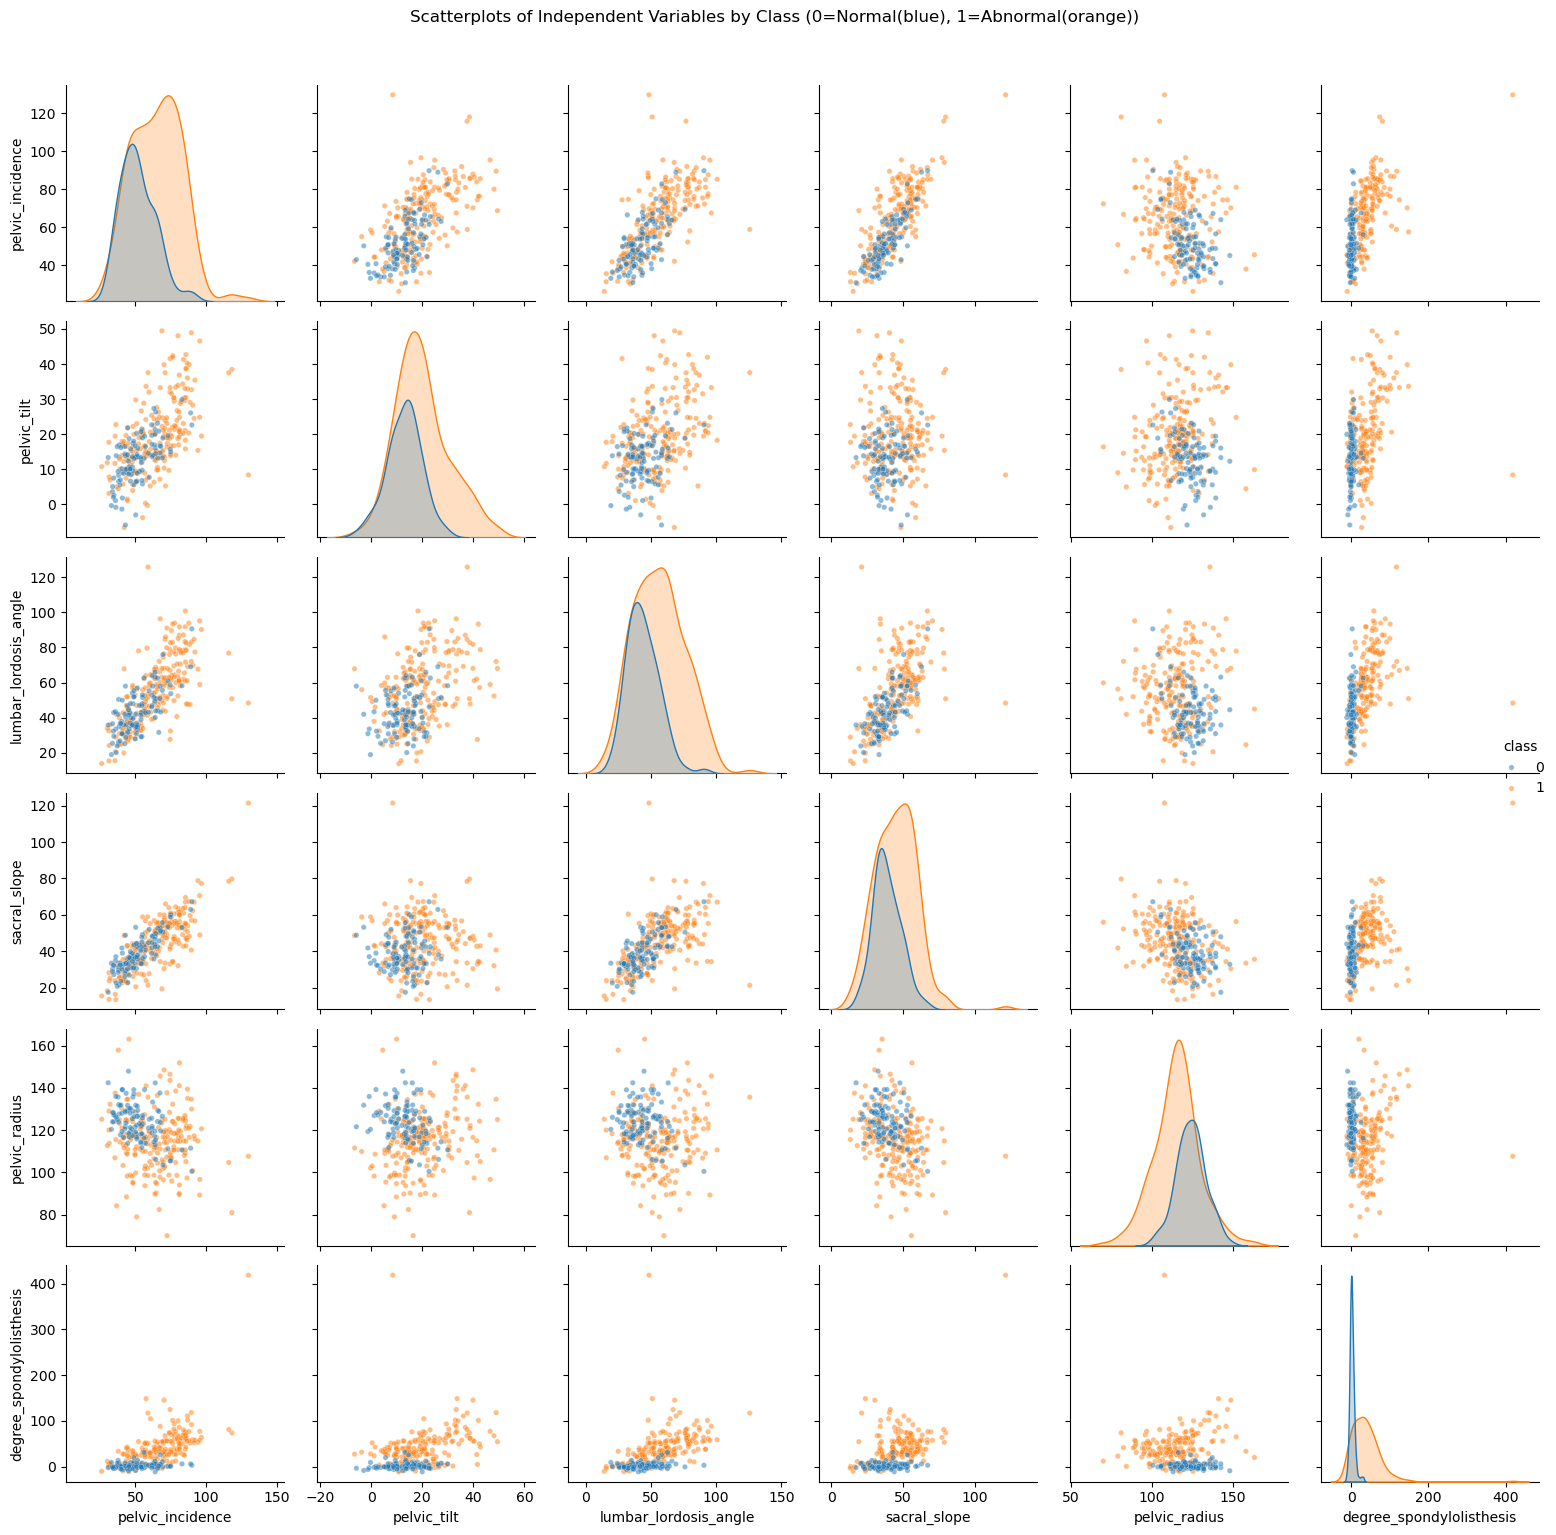

In [6]:
# ── (b)(i) Scatterplots of independent variables colored by class ─────────────
g = sns.pairplot(
    df, hue='class', palette=palette, vars=features,
    plot_kws={'alpha': 0.5, 's': 15}, diag_kind='kde'
)
g.figure.suptitle(
    'Scatterplots of Independent Variables by Class (0=Normal(blue), 1=Abnormal(orange))', y=1.02
)
plt.tight_layout()
plt.show()

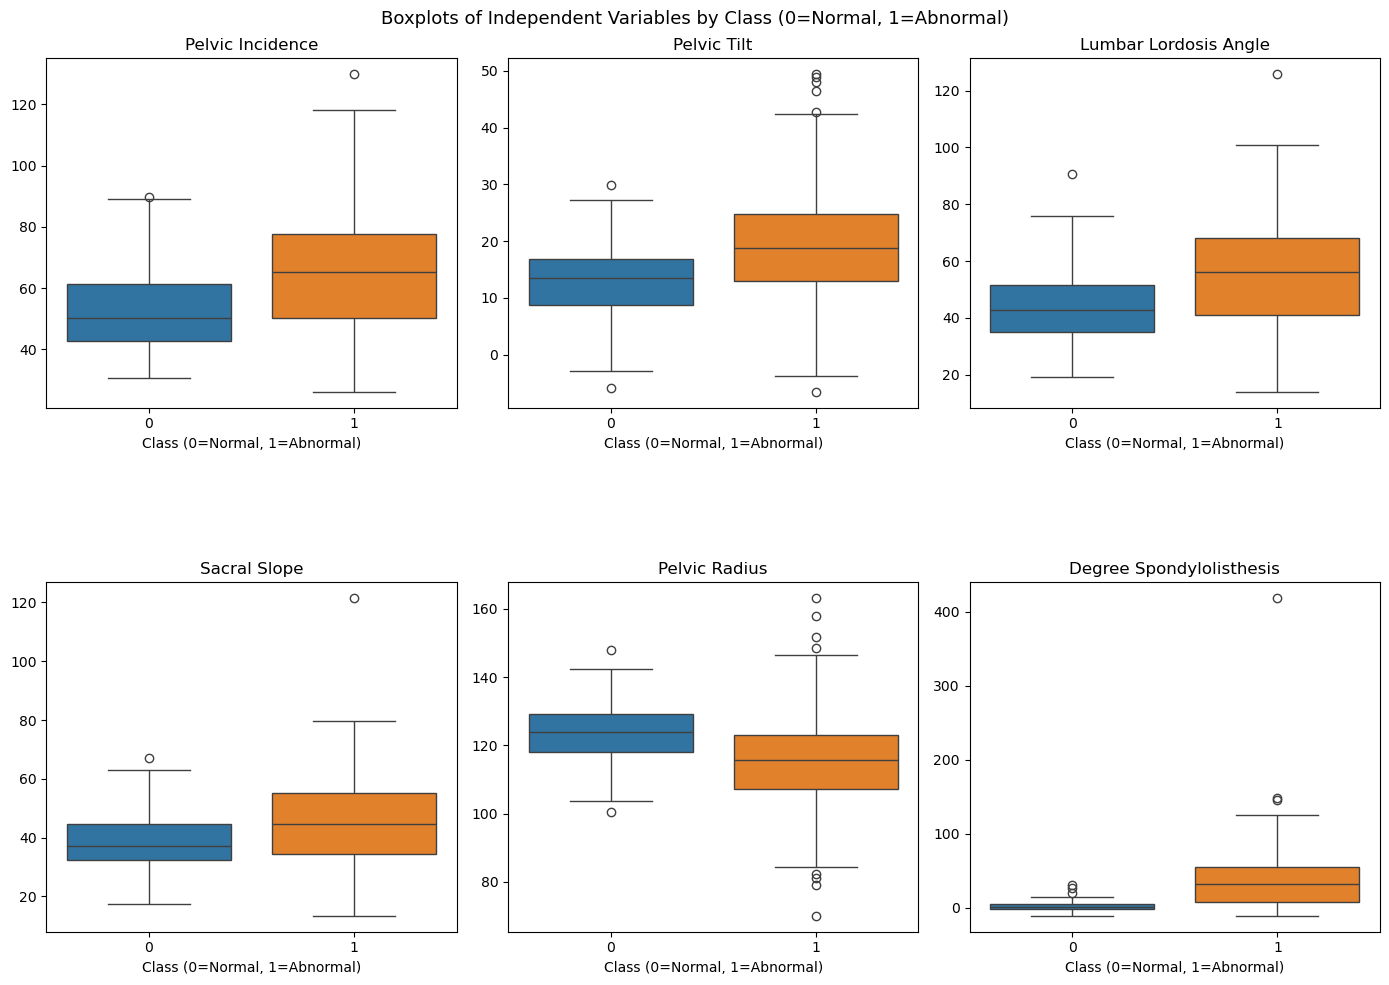

In [7]:
# ── (b)(ii) Boxplots of independent variables colored by class ───────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=df, x='class', y=feature,
        hue='class', palette=palette, legend=False, ax=ax
    )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Class (0=Normal, 1=Abnormal)')
    ax.set_ylabel('')

fig.suptitle('Boxplots of Independent Variables by Class (0=Normal, 1=Abnormal)', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

In [8]:
# ── (b)(iii) Train / test split ───────────────────────────────────────────────
class0 = df[df['class'] == 0]   # Normal  — 100 samples
class1 = df[df['class'] == 1]   # Abnormal — 210 samples

train = pd.concat([class0.iloc[:70], class1.iloc[:140]])
test  = pd.concat([class0.iloc[70:], class1.iloc[140:]])

X_train, y_train = train[features], train['class']
X_test,  y_test  = test[features],  test['class']

print(f"\nTraining set: {len(train)} samples  "
      f"(Class 0: {sum(y_train == 0)}, Class 1: {sum(y_train == 1)})")
print(f"Test set:     {len(test)} samples  "
      f"(Class 0: {sum(y_test == 0)}, Class 1: {sum(y_test == 1)})")


Training set: 210 samples  (Class 0: 70, Class 1: 140)
Test set:     100 samples  (Class 0: 30, Class 1: 70)


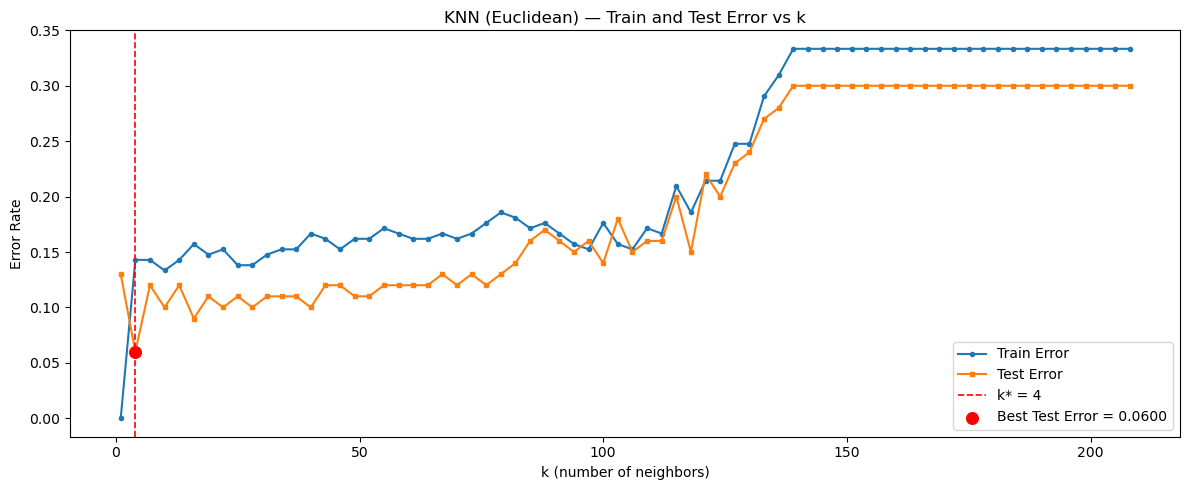


k* = 4  (test error = 0.0600)

Confusion Matrix (k = 4):
[[25  5]
 [ 1 69]]

True Positive Rate  (Recall):      0.9857
True Negative Rate  (Specificity): 0.8333
Precision:                         0.9324
F1-Score:                          0.9583


In [9]:
# ── (c)(i) KNN with Euclidean metric ─────────────────────────────────────────
# (c)(ii) Plot train/test errors for k in {208,205,...,7,4,1}; find k*; metrics
k_values = [k for k in range(208, 0, -3) if k <= len(X_train)]

train_errors, test_errors = [], []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    train_errors.append(1 - accuracy_score(y_train, knn.predict(X_train)))
    test_errors.append(1 - accuracy_score(y_test,   knn.predict(X_test)))

best_idx = test_errors.index(min(test_errors))
best_k   = k_values[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(k_values, train_errors, marker='o', markersize=3, label='Train Error')
plt.plot(k_values, test_errors,  marker='s', markersize=3, label='Test Error')
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.2, label=f'k* = {best_k}')
plt.scatter([best_k], [min(test_errors)], color='red', zorder=5, s=70,
            label=f'Best Test Error = {min(test_errors):.4f}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Error Rate')
plt.title('KNN (Euclidean) — Train and Test Error vs k')
plt.legend()
plt.tight_layout()
plt.show()

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)

print(f"\nk* = {best_k}  (test error = {min(test_errors):.4f})")
print(f"\nConfusion Matrix (k = {best_k}):\n{cm}")
print(f"\nTrue Positive Rate  (Recall):      {tpr:.4f}")
print(f"True Negative Rate  (Specificity): {tnr:.4f}")
print(f"Precision:                         {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score:                          {f1_score(y_test, y_pred):.4f}")

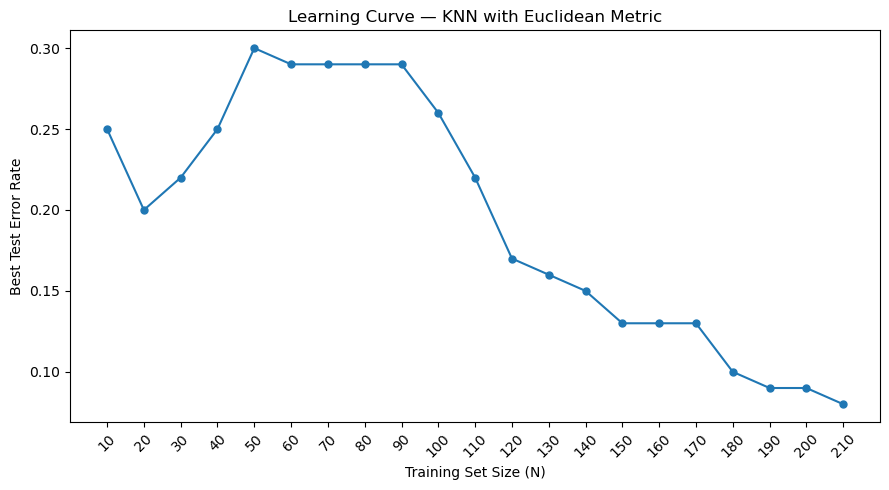

In [10]:
# ── (c)(iii) Learning Curve ───────────────────────────────────────────────────
# For each N in {10,20,...,210}: use first floor(N/3) rows of Class 0 and
# first N-floor(N/3) rows of Class 1 from the training set.
# Search k in {1,6,11,...} (step 5, starting from 1, up to N).
X_tr0 = X_train[y_train == 0]   # 70 Class-0 training rows
X_tr1 = X_train[y_train == 1]   # 140 Class-1 training rows
y_tr0 = y_train[y_train == 0]
y_tr1 = y_train[y_train == 1]

N_values        = list(range(10, 211, 10))
best_test_errors_lc = []

for N in N_values:
    n0 = N // 3       # floor(N/3) from Class 0
    n1 = N - n0       # N - floor(N/3) from Class 1

    X_sub = pd.concat([X_tr0.iloc[:n0], X_tr1.iloc[:n1]])
    y_sub = pd.concat([y_tr0.iloc[:n0], y_tr1.iloc[:n1]])

    k_candidates = [k for k in range(1, N, 5) if k <= len(X_sub)]
    best_err = float('inf')
    for k in k_candidates:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_sub, y_sub)
        err = 1 - accuracy_score(y_test, knn.predict(X_test))
        if err < best_err:
            best_err = err
    best_test_errors_lc.append(best_err)

plt.figure(figsize=(9, 5))
plt.plot(N_values, best_test_errors_lc, marker='o', markersize=5)
plt.xlabel('Training Set Size (N)')
plt.ylabel('Best Test Error Rate')
plt.title('Learning Curve — KNN with Euclidean Metric')
plt.xticks(N_values, rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# ── (d) Alternative distance metrics ─────────────────────────────────────────
k_set = [k for k in range(1, 197, 5) if k <= len(X_train)]   # {1,6,11,...,196}

def find_best_k(metric, p=None, VI=None):
    """Return (best_k, best_test_error) over k_set for a given metric."""
    best_err, best_k_ = float('inf'), k_set[0]
    for k in k_set:
        params = {'n_neighbors': k, 'metric': metric}
        if p   is not None: params['p']             = p
        if VI  is not None: params['metric_params'] = {'VI': VI}
        knn = KNeighborsClassifier(**params)
        knn.fit(X_train, y_train)
        err = 1 - accuracy_score(y_test, knn.predict(X_test))
        if err < best_err:
            best_err, best_k_ = err, k
    return best_k_, best_err

# (d)(i)(A) Manhattan (Minkowski p=1)
k_manh, err_manh = find_best_k('manhattan')

# (d)(i)(B) Minkowski, log10(p) in {0.1,0.2,...,1.0}, fix k = k_manh*
log_p_values = np.round(np.arange(0.1, 1.01, 0.1), 1)
best_log_p, best_err_mink = None, float('inf')
for log_p in log_p_values:
    knn = KNeighborsClassifier(n_neighbors=k_manh, metric='minkowski', p=10**log_p)
    knn.fit(X_train, y_train)
    err = 1 - accuracy_score(y_test, knn.predict(X_test))
    if err < best_err_mink:
        best_err_mink, best_log_p = err, log_p

# (d)(i)(C) Chebyshev (Minkowski p→∞)
k_cheb, err_cheb = find_best_k('chebyshev')

# (d)(ii) Mahalanobis
VI_mat = np.linalg.inv(np.cov(X_train.values.T))
k_maha, err_maha = find_best_k('mahalanobis', VI=VI_mat)

# Summary table
summary = pd.DataFrame([
    {'Metric': 'Euclidean',                          'k*': best_k,    'Test Error': min(test_errors)},
    {'Metric': 'Manhattan (p=1)',                    'k*': k_manh,    'Test Error': err_manh},
    {'Metric': f'Minkowski (log10(p)={best_log_p})', 'k*': k_manh,    'Test Error': best_err_mink},
    {'Metric': 'Chebyshev (p→∞)',                   'k*': k_cheb,    'Test Error': err_cheb},
    {'Metric': 'Mahalanobis',                        'k*': k_maha,    'Test Error': err_maha},
])
summary['Test Error'] = summary['Test Error'].round(4)
print("\n(d) Test errors at k* across metrics:")
print(summary.to_string(index=False))
print(f"\nBest log10(p) for Minkowski: {best_log_p}  (p = {10**best_log_p:.4f})")



(d) Test errors at k* across metrics:
                  Metric  k*  Test Error
               Euclidean   4        0.06
         Manhattan (p=1)   1        0.11
Minkowski (log10(p)=0.7)   1        0.11
         Chebyshev (p→∞)  16        0.08
             Mahalanobis   6        0.15

Best log10(p) for Minkowski: 0.7  (p = 5.0119)


In [15]:
# ── (e) Distance-weighted voting ─────────────────────────────────────────────
# Weight each neighbor inversely proportional to its distance (weights='distance')
weighted_rows = []
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    best_err_w, best_k_w = float('inf'), k_set[0]
    for k in k_set:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights='distance')
        knn.fit(X_train, y_train)
        err = 1 - accuracy_score(y_test, knn.predict(X_test))
        if err < best_err_w:
            best_err_w, best_k_w = err, k
    weighted_rows.append({'Metric': metric.capitalize(), 'k*': best_k_w,
                          'Best Test Error (weighted)': round(best_err_w, 4)})

weighted_summary = pd.DataFrame(weighted_rows)
print("\n(e) Distance-weighted voting — best test errors:")
print(weighted_summary.to_string(index=False))

# ── (f) Lowest training error achieved ───────────────────────────────────────
# train_errors from (c)(ii) covers k in {208,...,1} with Euclidean metric
lowest_train_err = min(train_errors)
lowest_train_k   = k_values[train_errors.index(lowest_train_err)]
print(f"\n(f) Lowest training error rate: {lowest_train_err:.4f}  (at k={lowest_train_k}, Euclidean)")


(e) Distance-weighted voting — best test errors:
   Metric  k*  Best Test Error (weighted)
Euclidean   6                        0.10
Manhattan  26                        0.10
Chebyshev  16                        0.11

(f) Lowest training error rate: 0.0000  (at k=1, Euclidean)
